In [1]:
import utils
from utils.load_variable import load_variables_for_all_years
from matplotlib import pyplot as plt
import xarray as xr
import calendar
import numpy as np
import seaborn as sns
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import calendar
import wesanderson

In [2]:
CDNUMC = load_variables_for_all_years('h0', 'CDNUMC')
TGCLDLWP = load_variables_for_all_years('h0', 'TGCLDLWP')

area = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/area_files/AREA.nc')
NPAC_bool = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPO/NPAC_mask.nc')
w = area.where(NPAC_bool, 0)

In [4]:
def npac_monthly_climatology(da, w_area):
    # NPAC area-weighted mean time series
    ts = da.weighted(w_area).mean(['lat', 'lon'])

    # monthly climatology (month=1..12)
    clim = ts.groupby('time.month').mean('time').roll(month=-1)

    return clim

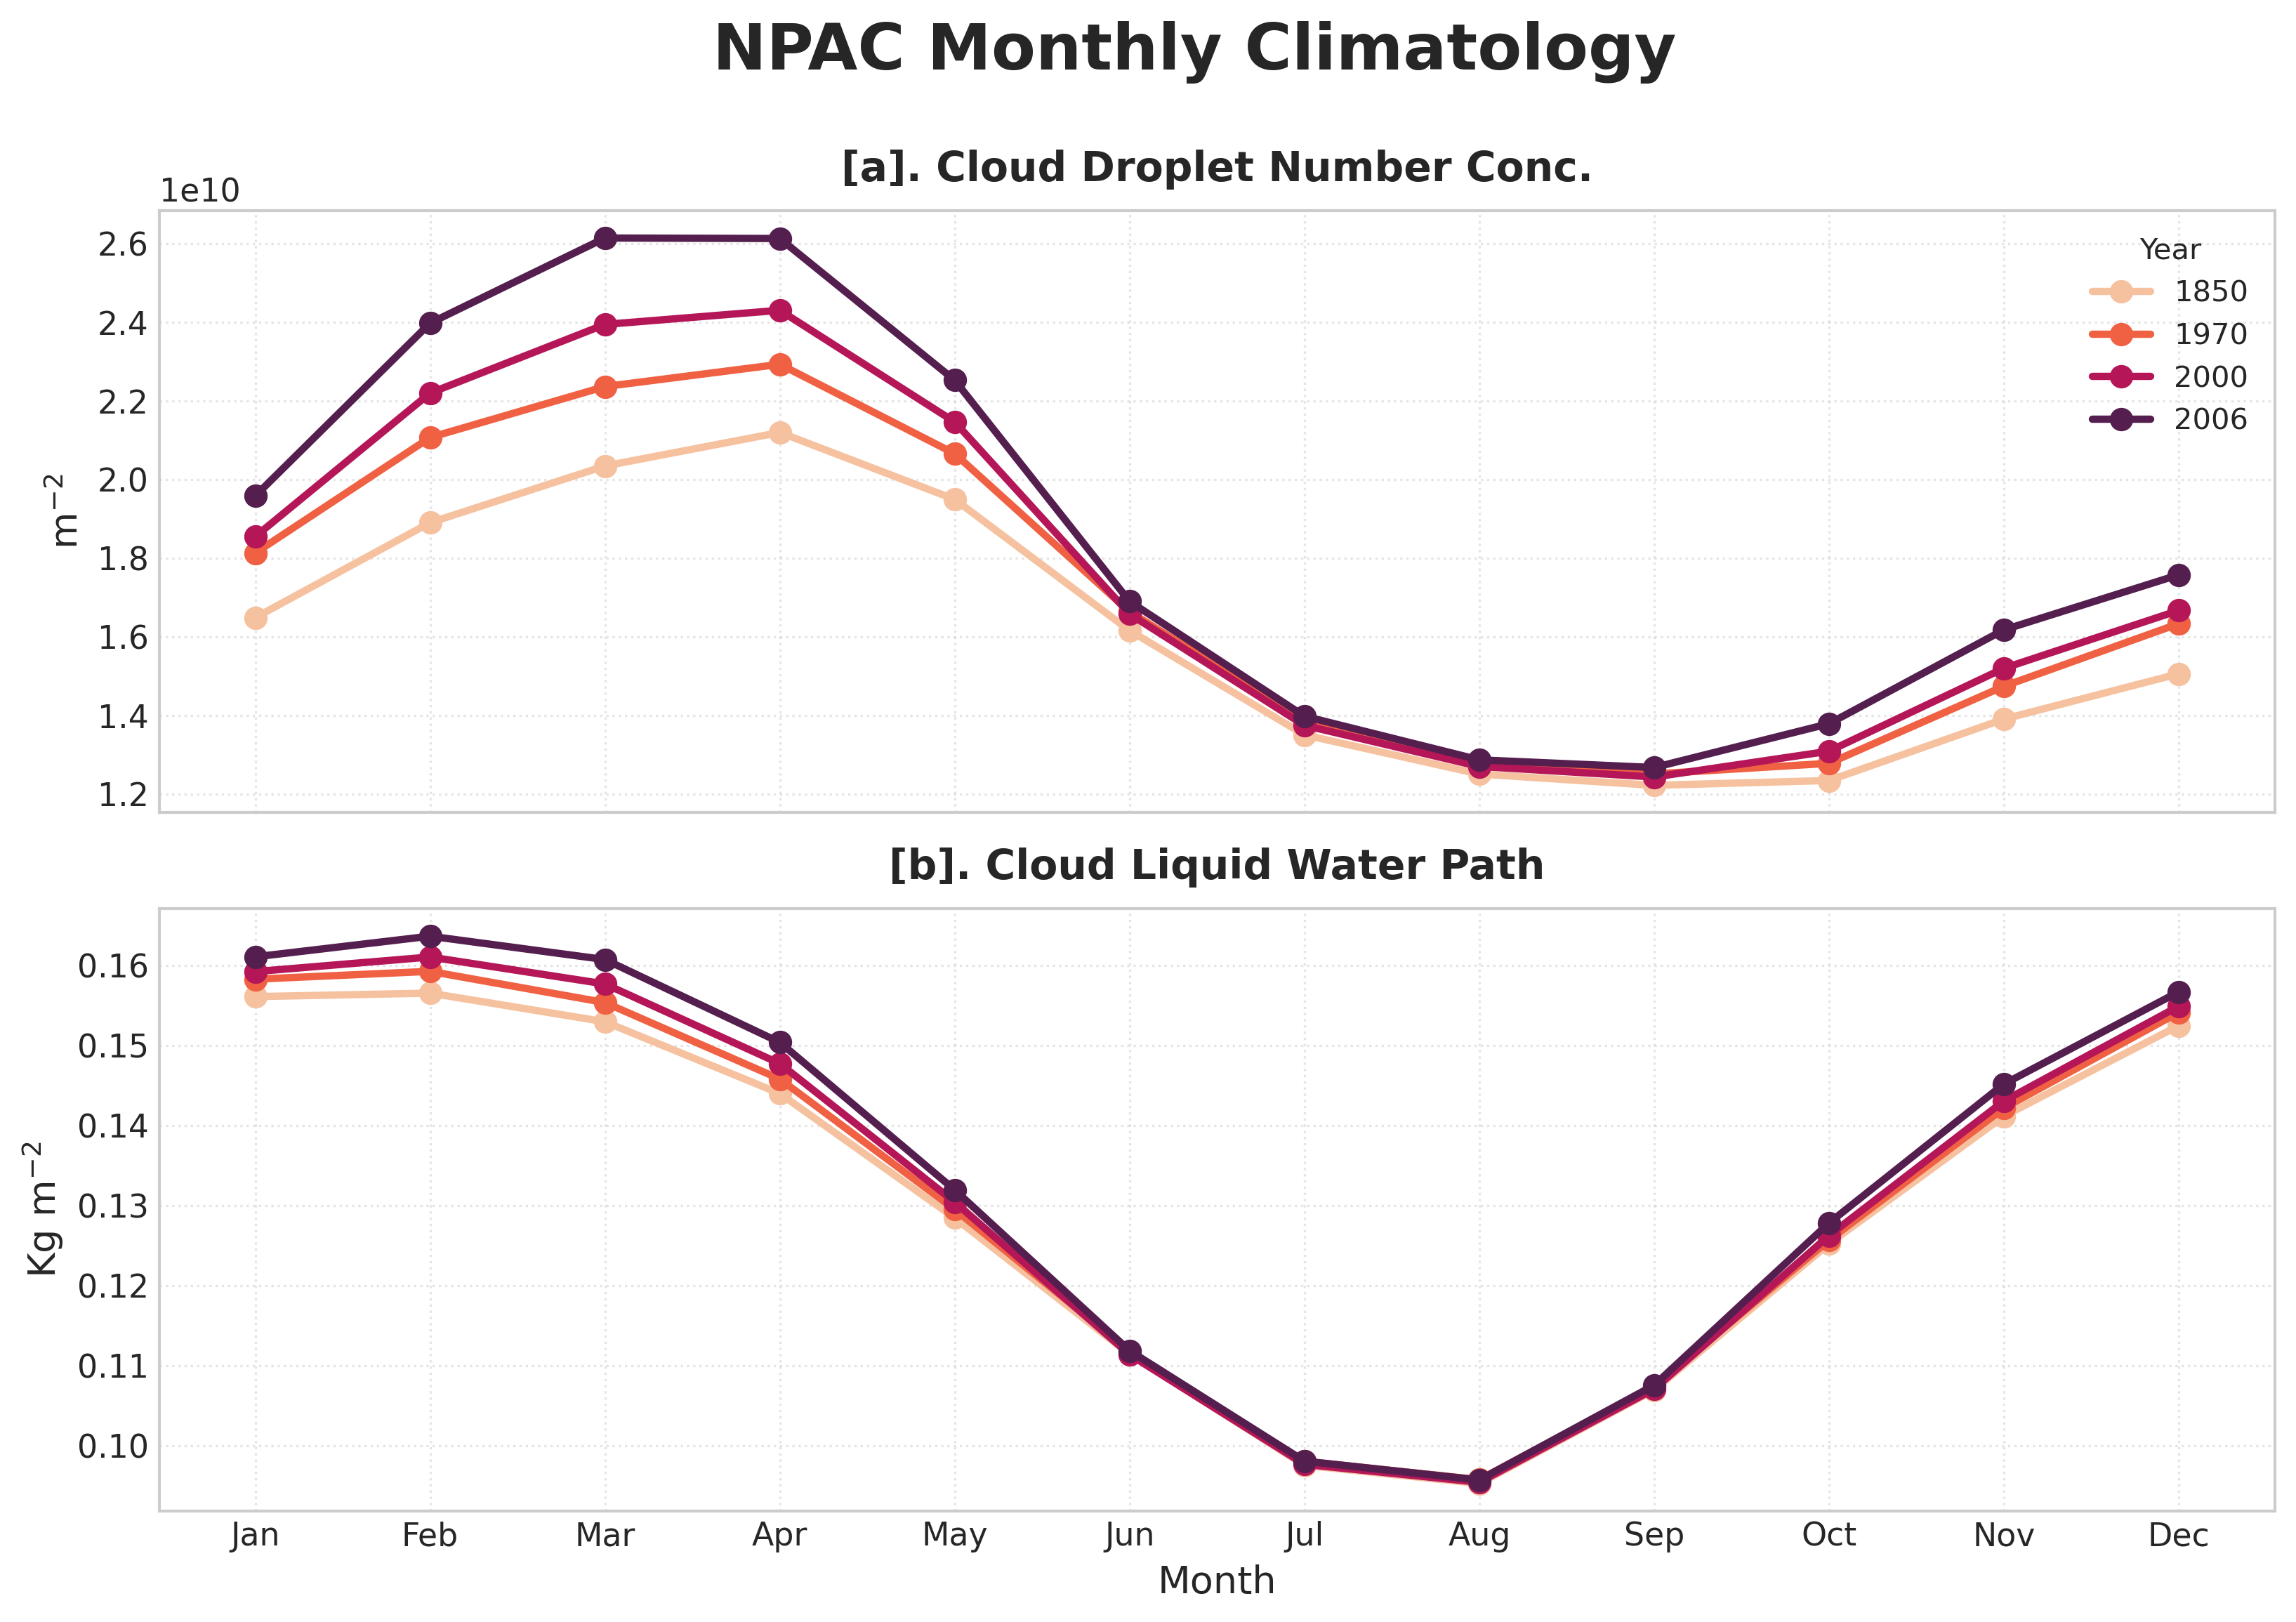

In [5]:
years = ["1850", "1970", "2000", "2006"]
months = [calendar.month_abbr[i] for i in range(1, 13)]

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"legend.frameon": False, "lines.linewidth": 2.5, "axes.titleweight": "bold", "axes.labelsize": 13, "xtick.labelsize": 11,"ytick.labelsize": 11,})

palette = sns.color_palette("rocket", 8)[::-2]
color_for = dict(zip(years, palette[:4]))

cdnumc_clim = {k: npac_monthly_climatology(CDNUMC[k], w) for k in years}
lwp_clim    = {k: npac_monthly_climatology(TGCLDLWP[k], w) for k in years}

# Figure
# ----------------------------
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), dpi=300, sharex=True)

# ----- (a) CDNUMC -----
ax1 = axes[0]
for k in years:
    ax1.plot(months, cdnumc_clim[k].values, label=k, color=color_for[k], marker="o", markersize=7)

ax1.set_ylabel("m$^{-2}$")
ax1.set_title("[a]. Cloud Droplet Number Conc.", fontsize=14, y=1.02)
ax1.grid(linestyle=":", alpha=0.5)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

# one clean legend (top panel)
ax1.legend(title="Year", loc="upper right", fontsize=10, title_fontsize=10)

# ----- (b) TGCLDLWP -----
ax2 = axes[1]
for k in years:
    ax2.plot(months, lwp_clim[k].values, color=color_for[k], marker="o", markersize=7)

ax2.set_ylabel("Kg m$^{-2}$")
ax2.set_title("[b]. Cloud Liquid Water Path", fontsize=14, y=1.02)
ax2.set_xlabel("Month")
ax2.grid(linestyle=":", alpha=0.5)


# Suptitle + spacing
# ----------------------------
fig.suptitle("NPAC Monthly Climatology", fontsize=22, weight="bold", x=0.52, y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

In [14]:
lwp_clim['2006'] / lwp_clim['2006'][0]

<xarray.DataArray 'TGCLDLWP' (month: 12)> Size: 48B
array([1.        , 1.0160143 , 0.99787384, 0.93359554, 0.8190149 ,
       0.69420063, 0.60851765, 0.5938508 , 0.6674053 , 0.7933664 ,
       0.90122783, 0.97281057], dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [16]:
lwp_clim['2006'] / lwp_clim['1970']

<xarray.DataArray 'TGCLDLWP' (month: 12)> Size: 48B
array([1.0176612, 1.027608 , 1.0346193, 1.0314496, 1.0188354, 1.0008234,
       1.000369 , 0.9995594, 1.0014215, 1.0170015, 1.0211993, 1.016661 ],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [17]:
lwp_clim['2006'] / lwp_clim['1970']

<xarray.DataArray 'TGCLDLWP' (month: 12)> Size: 48B
array([1.0176612, 1.027608 , 1.0346193, 1.0314496, 1.0188354, 1.0008234,
       1.000369 , 0.9995594, 1.0014215, 1.0170015, 1.0211993, 1.016661 ],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [21]:
300 * 0.003 * (0.5 - 0.1)

0.36000000000000004